# Adversarial URL Analysis / Hybrid Model

This notebook evaluates how controlled URL modifications affect the hybrid phishing detection model.

The hybrid approach combines:

- engineered structural and lexical URL features;
- the DistilBERT phishing-class logit;
- the DistilBERT phishing probability;
- a LightGBM classifier for the final prediction.

The analysis measures whether modified phishing URLs remain detectable after adding subdomains, tracking parameters, encoded paths, or simple homoglyph substitutions.

The results are intended as a practical robustness comparison with the DistilBERT-only model rather than a complete adversarial benchmark.

In [ ]:
from pathlib import Path
import sys
import urllib.parse as up

import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from tqdm import tqdm
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt


In [9]:
BASE_DIR = Path("..").resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"
BERT_DIR = BASE_DIR / "models" / "bert"


In [10]:
# src/features.py importieren
sys.path.append(str(BASE_DIR / "src"))
from features import build_features  # deine Feature-Funktion

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [12]:

# %% Daten laden
train_feat = pd.read_csv(PROCESSED_DIR / "urls_train_features.csv")
test_raw = pd.read_csv(PROCESSED_DIR / "urls_test.csv")  # roher Test für URLs/Labels

In [13]:
print("Train-Features:", train_feat.shape)
print("Test-Rohdaten:", test_raw.shape)

Train-Features: (439476, 24)
Test-Rohdaten: (110170, 3)


In [14]:

# %% BERT (für Hybrid-Features) laden
tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_DIR)
bert_model = DistilBertForSequenceClassification.from_pretrained(BERT_DIR).to(device)
bert_model.eval()
print("BERT geladen.")

BERT geladen.


In [15]:
# %% Helper: Dataset + BERT-Feature-Berechnung
class URLInferDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64):
        self.urls = df["url"].astype(str).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        url = self.urls[idx]
        enc = self.tokenizer(
            url,
            add_special_tokens=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
        }


def get_bert_features(df, tokenizer, model, device, batch_size=64, max_len=64):
    ds = URLInferDataset(df, tokenizer, max_len=max_len)
    dl = DataLoader(ds, batch_size=batch_size)

    model.eval()
    all_logits, all_probs = [], []

    with torch.no_grad():
        for batch in tqdm(dl, total=len(dl), desc="BERT feats"):
            input_ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)

            out = model(input_ids, attention_mask=mask)
            logits = out.logits
            prob = torch.softmax(logits, dim=1)[:, 1]

            all_logits.extend(logits[:, 1].cpu().tolist())
            all_probs.extend(prob.cpu().tolist())

    return pd.DataFrame(
        {
            "bert_logit": all_logits,
            "bert_proba": all_probs,
        }
    )

# %% Hybrid-Modell trainieren (Features + BERT auf Train-Set)


In [16]:
# Optional: Train-Sample für Geschwindigkeit
N_TRAIN = 100_000
if len(train_feat) > N_TRAIN:
    train_feat_sample = train_feat.sample(n=N_TRAIN, random_state=42).reset_index(drop=True)
else:
    train_feat_sample = train_feat.copy()

print("Hybrid-Traingröße:", len(train_feat_sample))

Hybrid-Traingröße: 100000


In [17]:
# Für BERT-Features brauchen wir ein DF mit Spalten url,label
train_base = train_feat_sample[["url", "label"]].copy()
bert_train_feats = get_bert_features(train_base, tokenizer, bert_model, device)

train_hybrid = pd.concat([train_feat_sample.reset_index(drop=True), bert_train_feats], axis=1)

drop_cols = ["url", "label"]
feature_cols = [c for c in train_hybrid.columns if c not in drop_cols]

BERT feats: 100%|██████████| 1563/1563 [01:27<00:00, 17.83it/s]


In [18]:

X_train = train_hybrid[feature_cols]
y_train = train_hybrid["label"]


In [19]:
hybrid_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42,
)
hybrid_model.fit(X_train, y_train)

print("Hybrid-Modell trainiert. Feature-Anzahl:", len(feature_cols))

[LightGBM] [Info] Number of positive: 28529, number of negative: 71471
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1383
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.285290 -> initscore=-0.918371
[LightGBM] [Info] Start training from score -0.918371
Hybrid-Modell trainiert. Feature-Anzahl: 24


In [20]:
# %% Phishing-URLs aus Testdaten auswählen
phish_raw = test_raw[test_raw["label"] == 1].reset_index(drop=True)
print("Phishing im Test:", len(phish_raw))

Phishing im Test: 31585


In [21]:
# Stichprobe für Adversarial-Analyse
N_PHISH = 2000
if len(phish_raw) > N_PHISH:
    phish_raw = phish_raw.sample(n=N_PHISH, random_state=42).reset_index(drop=True)

print("Phishing-Stichprobe:", len(phish_raw))

Phishing-Stichprobe: 2000


In [22]:
# %% Features + BERT-Features für Original-Phishing-URLs (Hybrid-TPs finden)

phish_base = phish_raw[["url", "label"]].copy()
phish_feat = build_features(phish_base)
bert_phish = get_bert_features(phish_base, tokenizer, bert_model, device)

phish_hybrid = pd.concat([phish_feat.reset_index(drop=True), bert_phish], axis=1)

X_phish = phish_hybrid[feature_cols]  # gleiche Feature-Spalten wie beim Training
proba_phish = hybrid_model.predict_proba(X_phish)[:, 1]
pred_phish = (proba_phish >= 0.5).astype(int)

phish_hybrid["hyb_pred"] = pred_phish
phish_hybrid["hyb_proba"] = proba_phish

# Nur True Positives (vom Hybrid korrekt erkannte Phishing-URLs)
phish_tp = phish_hybrid[phish_hybrid["hyb_pred"] == 1].reset_index(drop=True)
print("Hybrid-TPs in Phishing-Stichprobe:", len(phish_tp))

BERT feats: 100%|██████████| 32/32 [00:01<00:00, 16.59it/s]

Hybrid-TPs in Phishing-Stichprobe: 1937


In [23]:
# %% Adversarial-Angriffs-Funktionen
def ensure_http(url: str) -> str:
    if url.startswith(("http://", "https://")):
        return url
    return "http://" + url

def attack_subdomain(url: str) -> str:
    u = ensure_http(url)
    p = up.urlsplit(u)
    new_host = "sec-check." + p.netloc
    return up.urlunsplit((p.scheme, new_host, p.path, p.query, p.fragment))

def attack_tracking(url: str) -> str:
    u = ensure_http(url)
    p = up.urlsplit(u)
    extra = "utm_source=mail&utm_campaign=security"
    new_q = extra if not p.query else p.query + "&" + extra
    return up.urlunsplit((p.scheme, p.netloc, p.path, new_q, p.fragment))

def attack_encode(url: str) -> str:
    u = ensure_http(url)
    p = up.urlsplit(u)
    enc_path = up.quote(p.path, safe="/")
    return up.urlunsplit((p.scheme, p.netloc, enc_path, p.query, p.fragment))

def attack_homoglyph(url: str) -> str:
    u = str(url)
    return u.replace("login", "Iogin").replace("paypal", "paypaI")

attack_funcs = {
    "subdomain": attack_subdomain,
    "tracking": attack_tracking,
    "encode": attack_encode,
    "homoglyph": attack_homoglyph,
}

In [24]:
# %% Adversarial-URLs generieren
rows = []
for _, row in phish_tp.iterrows():
    orig = row["url"]
    for atk_name, fn in attack_funcs.items():
        adv = fn(orig)
        rows.append(
            {
                "url_orig": orig,
                "url_adv": adv,
                "label": 1,
                "attack": atk_name,
            }
        )

adv_df = pd.DataFrame(rows)
print("Anzahl adversarial URLs:", len(adv_df))
adv_df.head()


Anzahl adversarial URLs: 7748


,url_orig,url_adv,label,attack
0,myglyko.com/yyahook/yahoo.html,http://sec-check.myglyko.com/yyahook/yahoo.html,1,subdomain
1,myglyko.com/yyahook/yahoo.html,http://myglyko.com/yyahook/yahoo.html?utm_sour...,1,tracking
2,myglyko.com/yyahook/yahoo.html,http://myglyko.com/yyahook/yahoo.html,1,encode
3,myglyko.com/yyahook/yahoo.html,myglyko.com/yyahook/yahoo.html,1,homoglyph
4,helsby.biz/wtcui,http://sec-check.helsby.biz/wtcui,1,subdomain


In [25]:
# %% Features + BERT-Features für adversarial URLs berechnen

adv_base = adv_df[["url_adv", "label"]].rename(columns={"url_adv": "url"})
adv_feat = build_features(adv_base)
bert_adv = get_bert_features(adv_base, tokenizer, bert_model, device)

adv_hybrid = pd.concat([adv_df.reset_index(drop=True), adv_feat.reset_index(drop=True), bert_adv], axis=1)

X_adv = adv_hybrid[feature_cols]
proba_adv = hybrid_model.predict_proba(X_adv)[:, 1]
pred_adv = (proba_adv >= 0.5).astype(int)

adv_hybrid["hyb_pred"] = pred_adv
adv_hybrid["hyb_proba"] = proba_adv

adv_hybrid.head()


BERT feats: 100%|██████████| 122/122 [00:07<00:00, 16.16it/s]


,url_orig,url_adv,label,attack,url,label,url_len,num_digits,num_letters,num_slash,...,kw_update,kw_account,kw_bank,kw_paypal,kw_confirm,kw_free,bert_logit,bert_proba,hyb_pred,hyb_proba
0,myglyko.com/yyahook/yahoo.html,http://sec-check.myglyko.com/yyahook/yahoo.html,1,subdomain,http://sec-check.myglyko.com/yyahook/yahoo.html,1,47,0,38,4,...,0,0,0,0,0,0,4.158314,0.999578,1,1.000000
1,myglyko.com/yyahook/yahoo.html,http://myglyko.com/yyahook/yahoo.html?utm_sour...,1,tracking,http://myglyko.com/yyahook/yahoo.html?utm_sour...,1,75,0,62,4,...,0,0,0,0,0,0,3.326529,0.998074,1,1.000000
2,myglyko.com/yyahook/yahoo.html,http://myglyko.com/yyahook/yahoo.html,1,encode,http://myglyko.com/yyahook/yahoo.html,1,37,0,30,4,...,0,0,0,0,0,0,3.439903,0.998390,1,1.000000
3,myglyko.com/yyahook/yahoo.html,myglyko.com/yyahook/yahoo.html,1,homoglyph,myglyko.com/yyahook/yahoo.html,1,30,0,26,2,...,0,0,0,0,0,0,3.450333,0.998418,1,0.999999
4,helsby.biz/wtcui,http://sec-check.helsby.biz/wtcui,1,subdomain,http://sec-check.helsby.biz/wtcui,1,33,0,26,3,...,0,0,0,0,0,0,0.936365,0.841085,1,0.999981


In [26]:
# %% Erfolgsraten der Angriffe berechnen

stats = []
for atk in attack_funcs.keys():
    sub = adv_hybrid[adv_hybrid["attack"] == atk]
    total = len(sub)
    missed = (sub["hyb_pred"] == 0).sum()  # jetzt als legitim eingestuft
    rate = missed / total if total > 0 else 0.0
    stats.append(
        {
            "attack": atk,
            "n_total": total,
            "n_missed": missed,
            "adv_success_rate": rate,
        }
    )

hyb_adv_stats = pd.DataFrame(stats)
hyb_adv_stats


,attack,n_total,n_missed,adv_success_rate
0,subdomain,1937,2,0.001033
1,tracking,1937,24,0.012390
2,encode,1937,57,0.029427
3,homoglyph,1937,3,0.001549


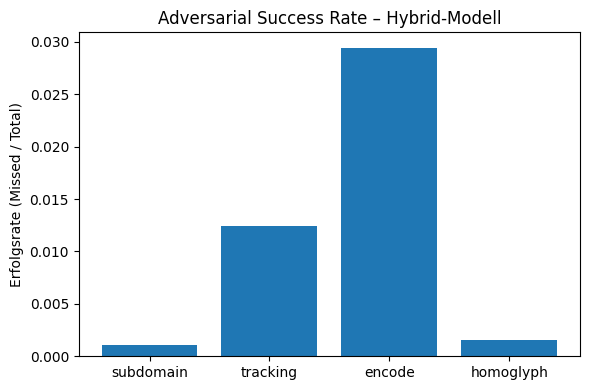

In [27]:
# %% Balkendiagramm der Erfolgsraten

plt.figure(figsize=(6,4))
plt.bar(hyb_adv_stats["attack"], hyb_adv_stats["adv_success_rate"])
plt.ylabel("Erfolgsrate (Missed / Total)")
plt.title("Adversarial Success Rate – Hybrid-Modell")
plt.tight_layout()
plt.show()

In [28]:
# %% Beispiele: Fehlklassifizierte adversarial URLs je Angriff

examples = []
for atk in attack_funcs.keys():
    sub = adv_hybrid[(adv_hybrid["attack"] == atk) & (adv_hybrid["hyb_pred"] == 0)]
    ex = sub.head(5)[["attack", "url_orig", "url_adv", "hyb_proba"]]
    examples.append(ex)

adv_examples = pd.concat(examples, ignore_index=True)
adv_examples

,attack,url_orig,url_adv,hyb_proba
0,subdomain,tk-gregoric.si,http://sec-check.tk-gregoric.si,0.458527
1,subdomain,jiang.aspx?e1=,http://sec-check.jiang.aspx?e1=,0.240453
2,tracking,deploy.html,http://deploy.html?utm_source=mail&utm_campaig...,0.007885
3,tracking,6b8a953b2bf7788063d5-6e453f33ecbb90f11a62a5c37...,http://6b8a953b2bf7788063d5-6e453f33ecbb90f11a...,0.209818
4,tracking,www.speedagecommercials.net/online.php,http://www.speedagecommercials.net/online.php?...,0.186905
5,tracking,eternitymobiles.com,http://eternitymobiles.com?utm_source=mail&utm...,0.000025
6,tracking,micro/advice.php?,http://micro/advice.php?utm_source=mail&utm_ca...,0.033014
7,encode,helsby.biz/wtcui,http://helsby.biz/wtcui,0.004311
8,encode,crownsaddler.com/prosseguir.php,http://crownsaddler.com/prosseguir.php,0.063056
9,encode,darkhollowcoffee.com/xlbps,http://darkhollowcoffee.com/xlbps,0.029145
